Goal is the creation of an automated predictive model capable of accurately forecasting whether a given loan application will be approved or rejected. The model should take into account a variety of features that can significantly affect the loan decision, including:


Demographic factors: Age, marital status, education level, and employment status, which often influence an applicant's financial stability and future earning potential.
Credit-related factors: Credit score, outstanding debts, and the applicant’s credit history, which are indicative of how reliable an individual has been in repaying previous debts.
Financial factors: Monthly income, loan amount, loan term, and debt-to-income ratio, which provide insight into an applicant’s ability to manage additional financial commitments.
Behavioral and socio-economic factors: Housing situation, type of employment, and other lifestyle-related information that can impact the applicant’s long-term financial behavior.
The traditional approach of loan approval heavily relies on the judgment of loan officers to interpret these factors and make decisions, which can often result in subjective and biased outcomes. The key problem this project seeks to address is automating this decision-making process using machine learning, ensuring that decisions are made based on data-driven insights rather than human judgment alone.

Furthermore, the model must be able to handle missing or incomplete data, as applicants may not always provide a full set of information. It should also account for the dynamic nature of financial conditions, adjusting predictions based on changes in an applicant’s financial standing over time.

In [55]:
# Importing Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [56]:
#Loading the Dataset
df = pd.read_csv("loan_approval_dataset.csv")  # replace with your file name
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [57]:
# Initial Data Exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [58]:
# Drop identifier column (not useful for prediction)
df = df.drop(columns=['loan_id'])

In [59]:
# Initial Data Exploration
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [60]:
#Identifying column names
df.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [61]:
# Data Cleaning
df.columns = df.columns.str.strip().str.replace(' ', '')

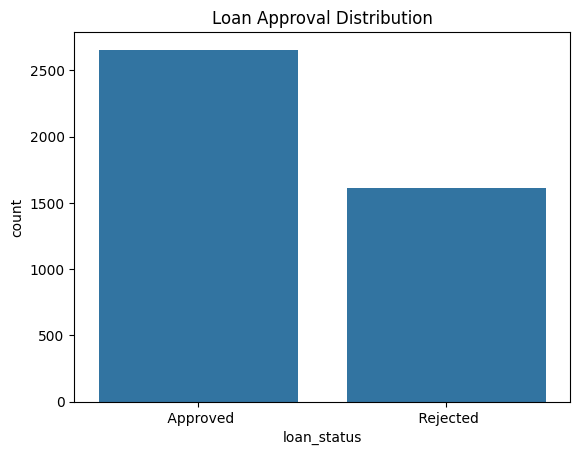

In [62]:
# Loan Approval Distribution
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

In [63]:
# Clean target column (remove spaces)
df['loan_status'] = df['loan_status'].str.strip()

# Encode target
df['loan_status'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})


In [64]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']


In [65]:
# Identification of Numerical and Categorical Features
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')
Categorical Columns: Index(['education', 'self_employed'], dtype='object')


In [74]:
# Data Preprocessing Pipeline Construction
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ]
)


In [67]:
# Train–Test Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [69]:
# Logistic Regression Model Evaluation
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Accuracy: 0.914519906323185

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854

ROC-AUC: 0.9725501857002092


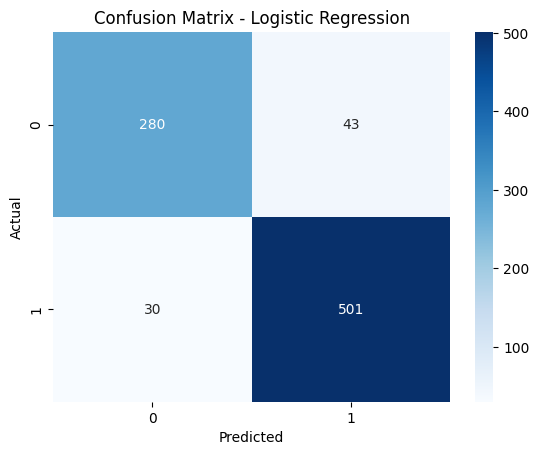

In [70]:
# Confusion Matrix Visualization – Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


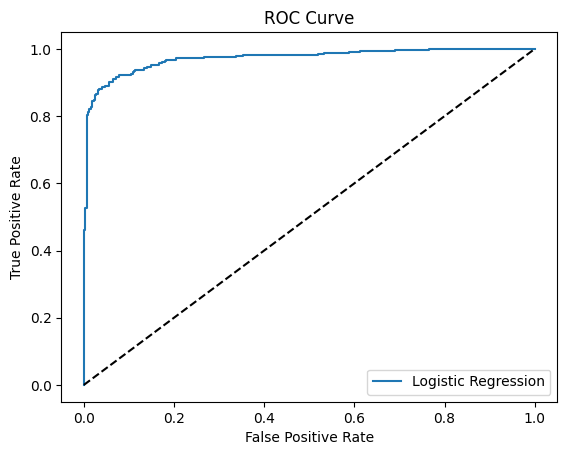

In [71]:
#Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [73]:
# Create a single test applicant using given columns
test_applicant = pd.DataFrame({
    #'loan_id': [999001],
    'no_of_dependents': [2],
    'education': ['Graduate'],
    'self_employed': ['No'],
    'income_annum': [750000],        # Annual income
    'loan_amount': [2500000],        # Loan amount
    'loan_term': [360],              # Loan term in months
    'cibil_score': [780],             # Good credit score
    'residential_assets_value': [1500000],
    'commercial_assets_value': [500000],
    'luxury_assets_value': [200000],
    'bank_asset_value': [800000]
})

# Predict loan approval using trained Logistic Regression pipeline
prediction = log_reg_pipeline.predict(test_applicant)
probability = log_reg_pipeline.predict_proba(test_applicant)

print("Predicted Loan Status:", "Approved" if prediction[0] == 1 else "Rejected")
print("Approval Probability:", round(probability[0][1], 2))


Predicted Loan Status: Rejected
Approval Probability: 0.0


##Conclusion

Logistic Regression – Model Evaluation Results
Overall Performance


- Accuracy: 91.45%


- ROC-AUC Score: 0.97


These results indicate that the Logistic Regression model demonstrates strong overall predictive performance and an excellent ability to distinguish between approved and rejected loan applications.


Interpretation

- The model performs very well for approved loans (Class 1):

    - High recall (94%) means most eligible applicants are correctly approved.

    - High precision (92%) indicates few false approvals.

- For rejected loans (Class 0):

    - The model maintains strong precision (90%), ensuring reliable rejection decisions.

    - Slightly lower recall (87%) suggests a small number of risky applicants may still be approved.
 
  Macro & Weighted Averages

- Macro F1-score (0.91): Indicates balanced performance across both classes.

- Weighted F1-score (0.91): Confirms the model performs consistently even with class imbalance.

ROC-AUC Interpretation

- A ROC-AUC of 0.97 reflects excellent class separation capability.

- The model is highly effective at ranking applicants by approval likelihood across different thresholds.

Conclusion

Logistic Regression proves to be a robust and reliable model for loan approval prediction, delivering high accuracy, strong class-wise performance, and excellent discrimination power. Its interpretability and stability make it well-suited for real-world financial decision-making systems.